In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import ast

In [3]:
'''
# 1. Define the base directory generically
DATA_DIR = Path('C:/Users/iamph/OneDrive/Documents/Datasets/Kaggle_Fitness_Workout_Dataset')

# 2. Safely join the path to the file
file_path = DATA_DIR / 'programs_detailed_boostcamp_kaggle.csv'
'''

# Run program summary dataset

In [3]:
# 1. Define the base directory generically
DATA_DIR = Path('C:/Users/iamph/OneDrive/Documents/Datasets/Kaggle_Fitness_Workout_Dataset')

# 2. Safely join the path to the file
file_path = DATA_DIR / 'program_summary.csv'

df = pd.read_csv(file_path)

In [4]:
df = pd.read_csv(file_path)

# Re-organise datasets and drop incomplete datapoints

In [5]:
df['level'] = df['level'].apply(ast.literal_eval)
df['goal'] = df['goal'].apply(ast.literal_eval)

In [6]:
df.shape

(2598, 10)

In [7]:
df.drop(1349, inplace = True) # Drop Lera -- workout program incomplete
df.drop(df[df.level.apply(len) == 0].index, inplace = True) #Drop programs which don't classify levels

In [8]:
df.shape

(2589, 10)

In [9]:
df.level = df.level.apply(set)

In [10]:
def set_mapping(s):
    if s == set(['Intermediate','Beginner']):
        s = set(['Intermediate', 'Novice', 'Beginner'])
    elif s == set(['Beginner', 'Advanced']):
        s = set(['Beginner', 'Novice', 'Intermediate', 'Advanced'])
    elif s == set(['Beginner', 'Intermediate', 'Advanced']):
        s = set(['Beginner', 'Novice', 'Intermediate', 'Advanced'])
    elif s == set(['Novice', 'Advanced']):
        s = set(['Novice', 'Intermediate', 'Advanced'])
    return s 

In [11]:
df.level = df.level.apply(set_mapping)

# Categorise Data

In [45]:
df['level'].explode().value_counts()

level
Intermediate    1918
Novice          1316
Advanced         848
Beginner         737
Name: count, dtype: int64

In [46]:
df['goal'].explode().value_counts()

goal
Bodybuilding             1723
Muscle & Sculpting        935
Powerbuilding             905
Athletics                 538
Powerlifting              494
Bodyweight Fitness        322
Olympic Weightlifting      39
Name: count, dtype: int64

([<matplotlib.axis.XTick at 0x283986d5c10>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17')])

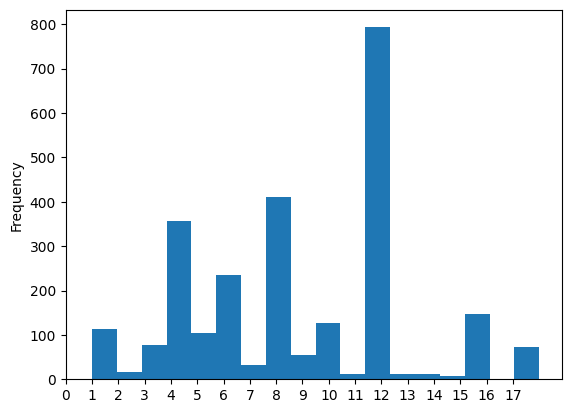

In [47]:
# Program Length
df.program_length.plot.hist(bins = 18)
plt.xticks(list(range(18)))

In [48]:
df.program_length.value_counts().sort_index()

program_length
1.0     113
2.0      17
3.0      78
4.0     357
5.0     105
6.0     235
7.0      32
8.0     411
9.0      55
10.0    127
11.0     13
12.0    793
13.0     12
14.0     13
15.0      8
16.0    146
17.0      1
18.0     73
Name: count, dtype: int64

In [49]:
test = df.level.explode() == 'Beginner'
test[test == 1].index
df.loc[list(test[test == 1].index),:].program_length.value_counts().sort_index()

program_length
1.0      36
2.0       6
3.0      20
4.0      91
5.0      29
6.0      74
7.0       4
8.0     116
9.0      18
10.0     36
11.0      6
12.0    226
13.0      7
14.0      4
15.0      2
16.0     44
18.0     18
Name: count, dtype: int64

In [50]:
df.loc[list(test[test == 1].index),:].program_length.value_counts().sort_index()/len(test[test == 1])

program_length
1.0     0.048847
2.0     0.008141
3.0     0.027137
4.0     0.123474
5.0     0.039349
6.0     0.100407
7.0     0.005427
8.0     0.157395
9.0     0.024423
10.0    0.048847
11.0    0.008141
12.0    0.306649
13.0    0.009498
14.0    0.005427
15.0    0.002714
16.0    0.059701
18.0    0.024423
Name: count, dtype: float64

In [51]:
test = df.level.explode() == 'Novice'
test[test == 1].index
df.loc[list(test[test == 1].index),:].program_length.value_counts().sort_index()

program_length
1.0      63
2.0      10
3.0      35
4.0     169
5.0      47
6.0     135
7.0      15
8.0     219
9.0      24
10.0     63
11.0      6
12.0    387
13.0      9
14.0      5
15.0      4
16.0     82
18.0     43
Name: count, dtype: int64

In [52]:
test = df.level.explode() == 'Intermediate'
test[test == 1].index
df.loc[list(test[test == 1].index),:].program_length.value_counts().sort_index()

program_length
1.0      83
2.0      11
3.0      59
4.0     264
5.0      76
6.0     177
7.0      26
8.0     305
9.0      39
10.0    100
11.0      8
12.0    583
13.0      9
14.0      8
15.0      6
16.0    110
17.0      1
18.0     53
Name: count, dtype: int64

In [53]:
test = df.level.explode() == 'Advanced'
test[test == 1].index
df.loc[list(test[test == 1].index),:].program_length.value_counts().sort_index()

program_length
1.0      34
2.0       3
3.0      28
4.0     122
5.0      32
6.0      84
7.0       9
8.0     135
9.0      12
10.0     43
11.0      4
12.0    255
13.0      3
14.0      1
15.0      3
16.0     54
17.0      1
18.0     25
Name: count, dtype: int64

In [54]:
df.equipment.value_counts()

equipment
Full Gym         1842
Garage Gym        560
At Home           119
Dumbbell Only      68
Name: count, dtype: int64

<Axes: >

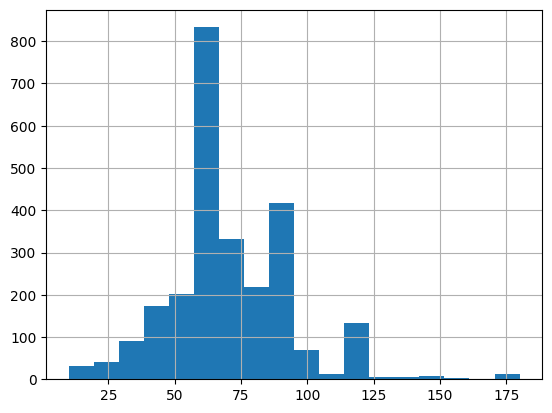

In [55]:
df.time_per_workout.hist(bins = 18)

<Axes: >

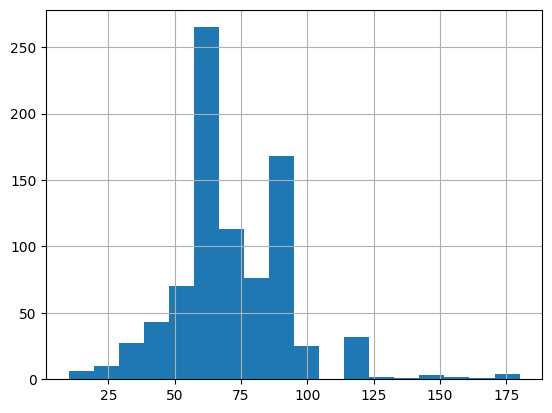

In [27]:
test = df.level.explode() == 'Advanced'
test[test == 1].index
df.loc[list(test[test == 1].index),:].time_per_workout.hist(bins = 18)

<Axes: >

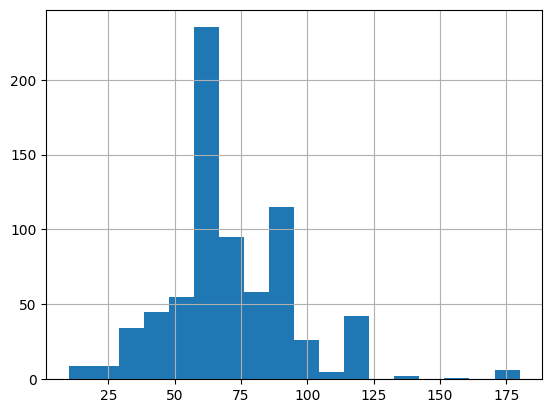

In [28]:
test = df.level.explode() == 'Beginner'
test[test == 1].index
df.loc[list(test[test == 1].index),:].time_per_workout.hist(bins = 18)

In [29]:
df.goal.explode().value_counts(dropna=False)

goal
Bodybuilding             1723
Muscle & Sculpting        935
Powerbuilding             905
Athletics                 538
Powerlifting              494
Bodyweight Fitness        322
Olympic Weightlifting      39
Name: count, dtype: int64

In [30]:
df.shape

(2589, 10)

In [31]:
df.goal.explode().value_counts(dropna=False)/len(df)

goal
Bodybuilding             0.665508
Muscle & Sculpting       0.361143
Powerbuilding            0.349556
Athletics                0.207802
Powerlifting             0.190807
Bodyweight Fitness       0.124372
Olympic Weightlifting    0.015064
Name: count, dtype: float64

In [36]:
df.goal.apply(set).value_counts().head(25)

goal
{Bodybuilding}                                                                574
{Muscle & Sculpting, Bodybuilding}                                            332
{Bodybuilding, Powerbuilding}                                                 177
{Powerbuilding}                                                               173
{Muscle & Sculpting}                                                          145
{Bodybuilding, Powerbuilding, Powerlifting}                                   112
{Powerbuilding, Powerlifting}                                                 104
{Athletics}                                                                    91
{Muscle & Sculpting, Bodybuilding, Powerbuilding}                              80
{Powerlifting}                                                                 73
{Muscle & Sculpting, Athletics, Bodybuilding}                                  66
{Athletics, Bodybuilding}                                                      57
{Muscle & S

In [37]:
df.level.apply(len).value_counts()

level
1    1124
2     940
3     323
4     202
Name: count, dtype: int64

In [43]:
df.level.value_counts()

level
{Intermediate}                                621
{Intermediate, Novice}                        374
{Intermediate, Advanced}                      366
{Novice}                                      217
{Intermediate, Beginner, Advanced, Novice}    208
{Intermediate, Beginner, Novice}              196
{Beginner, Novice}                            168
{Beginner}                                    165
{Intermediate, Advanced, Novice}              153
{Advanced}                                    121
Name: count, dtype: int64

In [44]:
df.level.explode().value_counts()

level
Intermediate    1918
Novice          1316
Advanced         848
Beginner         737
Name: count, dtype: int64

# Workout Focus by level

In [77]:
test = df.level.explode() == 'Beginner'
test[test == 1].index
df.loc[list(test[test == 1].index),:].goal.explode().value_counts()

goal
Bodybuilding             437
Muscle & Sculpting       286
Athletics                210
Powerbuilding            199
Bodyweight Fitness       142
Powerlifting             122
Olympic Weightlifting      8
Name: count, dtype: int64

In [78]:
(df.loc[list(test[test == 1].index),:].goal.explode().value_counts()/len(test[test == 1].index)).round(3)

goal
Bodybuilding             0.593
Muscle & Sculpting       0.388
Athletics                0.285
Powerbuilding            0.270
Bodyweight Fitness       0.193
Powerlifting             0.166
Olympic Weightlifting    0.011
Name: count, dtype: float64

In [79]:
test = df.level.explode() == 'Novice'
test[test == 1].index
df.loc[list(test[test == 1].index),:].goal.explode().value_counts()

goal
Bodybuilding             879
Muscle & Sculpting       512
Powerbuilding            465
Athletics                275
Powerlifting             250
Bodyweight Fitness       173
Olympic Weightlifting     14
Name: count, dtype: int64

In [80]:
(df.loc[list(test[test == 1].index),:].goal.explode().value_counts()/len(test[test == 1].index)).round(3)

goal
Bodybuilding             0.668
Muscle & Sculpting       0.389
Powerbuilding            0.353
Athletics                0.209
Powerlifting             0.190
Bodyweight Fitness       0.131
Olympic Weightlifting    0.011
Name: count, dtype: float64

In [82]:
test = df.level.explode() == 'Intermediate'
test[test == 1].index
df.loc[list(test[test == 1].index),:].goal.explode().value_counts()

goal
Bodybuilding             1311
Powerbuilding             761
Muscle & Sculpting        716
Athletics                 396
Powerlifting              383
Bodyweight Fitness        218
Olympic Weightlifting      28
Name: count, dtype: int64

In [83]:
(df.loc[list(test[test == 1].index),:].goal.explode().value_counts()/len(test[test == 1].index)).round(3)

goal
Bodybuilding             0.684
Powerbuilding            0.397
Muscle & Sculpting       0.373
Athletics                0.206
Powerlifting             0.200
Bodyweight Fitness       0.114
Olympic Weightlifting    0.015
Name: count, dtype: float64

In [84]:
test = df.level.explode() == 'Advanced'
test[test == 1].index
df.loc[list(test[test == 1].index),:].goal.explode().value_counts()

goal
Bodybuilding             620
Powerbuilding            365
Muscle & Sculpting       322
Powerlifting             205
Athletics                186
Bodyweight Fitness       111
Olympic Weightlifting     26
Name: count, dtype: int64

In [86]:
(df.loc[list(test[test == 1].index),:].goal.explode().value_counts()/len(test[test == 1].index)).round(3)

goal
Bodybuilding             0.731
Powerbuilding            0.430
Muscle & Sculpting       0.380
Powerlifting             0.242
Athletics                0.219
Bodyweight Fitness       0.131
Olympic Weightlifting    0.031
Name: count, dtype: float64

In [71]:
df.goal.explode().value_counts()

goal
Bodybuilding             1723
Muscle & Sculpting        935
Powerbuilding             905
Athletics                 538
Powerlifting              494
Bodyweight Fitness        322
Olympic Weightlifting      39
Name: count, dtype: int64

In [87]:
(df.goal.explode().value_counts()/len(df)).round(3)

goal
Bodybuilding             0.666
Muscle & Sculpting       0.361
Powerbuilding            0.350
Athletics                0.208
Powerlifting             0.191
Bodyweight Fitness       0.124
Olympic Weightlifting    0.015
Name: count, dtype: float64

# Equipment by level

In [93]:
test = df.level.explode() == 'Beginner'
test[test == 1].index
df.loc[list(test[test == 1].index),:].equipment.value_counts()

equipment
Full Gym         550
Garage Gym       136
At Home           31
Dumbbell Only     20
Name: count, dtype: int64

In [94]:
(df.loc[list(test[test == 1].index),:].equipment.explode().value_counts()/len(test[test == 1].index)).round(3)

equipment
Full Gym         0.746
Garage Gym       0.185
At Home          0.042
Dumbbell Only    0.027
Name: count, dtype: float64

In [95]:
test = df.level.explode() == 'Novice'
test[test == 1].index
df.loc[list(test[test == 1].index),:].equipment.value_counts()

equipment
Full Gym         943
Garage Gym       273
At Home           63
Dumbbell Only     37
Name: count, dtype: int64

In [96]:
(df.loc[list(test[test == 1].index),:].equipment.explode().value_counts()/len(test[test == 1].index)).round(3)

equipment
Full Gym         0.717
Garage Gym       0.207
At Home          0.048
Dumbbell Only    0.028
Name: count, dtype: float64

In [97]:
test = df.level.explode() == 'Intermediate'
test[test == 1].index
df.loc[list(test[test == 1].index),:].equipment.value_counts()

equipment
Full Gym         1361
Garage Gym        420
At Home            89
Dumbbell Only      48
Name: count, dtype: int64

In [98]:
(df.loc[list(test[test == 1].index),:].equipment.explode().value_counts()/len(test[test == 1].index)).round(3)

equipment
Full Gym         0.710
Garage Gym       0.219
At Home          0.046
Dumbbell Only    0.025
Name: count, dtype: float64

In [99]:
test = df.level.explode() == 'Advanced'
test[test == 1].index
df.loc[list(test[test == 1].index),:].equipment.value_counts()

equipment
Full Gym         604
Garage Gym       203
At Home           27
Dumbbell Only     14
Name: count, dtype: int64

In [100]:
(df.loc[list(test[test == 1].index),:].equipment.explode().value_counts()/len(test[test == 1].index)).round(3)

equipment
Full Gym         0.712
Garage Gym       0.239
At Home          0.032
Dumbbell Only    0.017
Name: count, dtype: float64

In [101]:
df.equipment.value_counts()

equipment
Full Gym         1842
Garage Gym        560
At Home           119
Dumbbell Only      68
Name: count, dtype: int64

In [103]:
(df.equipment.value_counts()/len(df)).round(3)

equipment
Full Gym         0.711
Garage Gym       0.216
At Home          0.046
Dumbbell Only    0.026
Name: count, dtype: float64

# Relationship between equipment and goals

In [104]:
test = df.equipment == 'Full Gym'
test[test == 1].index
df.loc[list(test[test == 1].index),:].goal.explode().value_counts()

goal
Bodybuilding             1214
Powerbuilding             669
Muscle & Sculpting        663
Athletics                 384
Powerlifting              355
Bodyweight Fitness        221
Olympic Weightlifting      27
Name: count, dtype: int64

In [107]:
test = df.equipment == 'Full Gym'
test[test == 1].index
df.loc[list(test[test == 1].index),:].goal.explode().value_counts()/len(test[test == 1].index)

goal
Bodybuilding             0.659066
Powerbuilding            0.363192
Muscle & Sculpting       0.359935
Athletics                0.208469
Powerlifting             0.192725
Bodyweight Fitness       0.119978
Olympic Weightlifting    0.014658
Name: count, dtype: float64

In [108]:
test = df.equipment == 'Garage Gym'
test[test == 1].index
df.loc[list(test[test == 1].index),:].goal.explode().value_counts()/len(test[test == 1].index)

goal
Bodybuilding             0.685714
Muscle & Sculpting       0.369643
Powerbuilding            0.323214
Athletics                0.210714
Powerlifting             0.192857
Bodyweight Fitness       0.133929
Olympic Weightlifting    0.017857
Name: count, dtype: float64

In [109]:
test = df.equipment == 'At Home'
test[test == 1].index
df.loc[list(test[test == 1].index),:].goal.explode().value_counts()/len(test[test == 1].index)

goal
Bodybuilding             0.705882
Muscle & Sculpting       0.386555
Powerbuilding            0.285714
Athletics                0.193277
Bodyweight Fitness       0.151261
Powerlifting             0.134454
Olympic Weightlifting    0.008403
Name: count, dtype: float64

In [110]:
test = df.equipment == 'Dumbbell Only'
test[test == 1].index
df.loc[list(test[test == 1].index),:].goal.explode().value_counts()/len(test[test == 1].index)

goal
Bodybuilding             0.602941
Powerbuilding            0.308824
Muscle & Sculpting       0.279412
Powerlifting             0.220588
Athletics                0.191176
Bodyweight Fitness       0.117647
Olympic Weightlifting    0.014706
Name: count, dtype: float64

# Analysis of Exercises

In [115]:
# 1. Define the base directory generically
DATA_DIR = Path('C:/Users/iamph/OneDrive/Documents/Datasets/Kaggle_Fitness_Workout_Dataset')

# 2. Safely join the path to the file
file_path = DATA_DIR / 'programs_detailed_boostcamp_kaggle.csv'

ex = pd.read_csv(file_path)

In [112]:
ex.head(5)

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
0,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Knee-to-wall ankle dorsiflexion test,3.0,-180.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
1,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Banded ankle distractions,3.0,-18.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
2,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Slant board calf stretch,3.0,-18.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
3,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Seated Tibialis Raise,3.0,15.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
4,Weightlifting Mobility program,This program is designed to help athletes succ...,"['Beginner', 'Novice', 'Intermediate', 'Advanc...","['Olympic Weightlifting', 'Muscle & Sculpting'...",Garage Gym,7.0,50.0,1.0,1.0,16.0,90/90 Hip Rotations,3.0,8.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00


## Clean exercise dataset

In [116]:
ex['level'] = ex['level'].apply(ast.literal_eval)
ex['goal'] = ex['goal'].apply(ast.literal_eval)

In [ ]:
'''
df.drop(1349, inplace = True) # Drop Lera -- workout program incomplete
df.drop(df[df.level.apply(len) == 0].index, inplace = True) #Drop programs which don't classify levels
'''

In [117]:
ex.level = ex.level.apply(set)

In [118]:
ex.level = ex.level.apply(set_mapping)

In [119]:
ex.head(5)

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
0,Weightlifting Mobility program,This program is designed to help athletes succ...,"{Intermediate, Beginner, Advanced, Novice}","[Olympic Weightlifting, Muscle & Sculpting, Bo...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Knee-to-wall ankle dorsiflexion test,3.0,-180.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
1,Weightlifting Mobility program,This program is designed to help athletes succ...,"{Intermediate, Beginner, Advanced, Novice}","[Olympic Weightlifting, Muscle & Sculpting, Bo...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Banded ankle distractions,3.0,-18.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
2,Weightlifting Mobility program,This program is designed to help athletes succ...,"{Intermediate, Beginner, Advanced, Novice}","[Olympic Weightlifting, Muscle & Sculpting, Bo...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Slant board calf stretch,3.0,-18.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
3,Weightlifting Mobility program,This program is designed to help athletes succ...,"{Intermediate, Beginner, Advanced, Novice}","[Olympic Weightlifting, Muscle & Sculpting, Bo...",Garage Gym,7.0,50.0,1.0,1.0,16.0,Seated Tibialis Raise,3.0,15.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00
4,Weightlifting Mobility program,This program is designed to help athletes succ...,"{Intermediate, Beginner, Advanced, Novice}","[Olympic Weightlifting, Muscle & Sculpting, Bo...",Garage Gym,7.0,50.0,1.0,1.0,16.0,90/90 Hip Rotations,3.0,8.0,6.0,2025-03-09 04:11:00,2025-06-23 03:31:00


# Analysis of Exercise per week and exercises per time

In [121]:
df.head()

,title,description,level,goal,equipment,program_length,time_per_workout,total_exercises,created,last_edit
0,(MASS MONSTER) High Intensity 4 Day Upper Lowe...,Build tones of muscular with this high intensi...,{Intermediate},"[Muscle & Sculpting, Bodyweight Fitness]",Full Gym,12.0,90.0,384,2024-01-20 10:23:00,2025-06-29 12:39:00
1,(NOT MY PROGRAM)SHJ Jotaro,Build strength and size,"{Intermediate, Advanced}",[Bodybuilding],Full Gym,8.0,60.0,224,2024-07-08 02:28:00,2025-06-18 09:15:00
2,1 PowerLift Per Day Powerbuilding 5 Day Bro Split,Based off of Andy Baker's KCS (Kingwood Streng...,"{Intermediate, Beginner, Novice}","[Athletics, Powerlifting, Powerbuilding]",Full Gym,6.0,90.0,237,2025-04-23 09:21:00,2025-06-18 11:55:00
3,10 Week Mass Building Program,This workout is designed to increase your musc...,"{Intermediate, Advanced}",[Powerbuilding],Garage Gym,10.0,70.0,280,2024-09-07 03:44:00,2025-06-18 08:01:00
4,10 week deadlift focus,Increase deadlift,"{Intermediate, Advanced}","[Powerbuilding, Powerlifting, Bodybuilding, Mu...",Full Gym,10.0,80.0,356,2024-12-23 03:13:00,2025-06-18 12:19:00


In [122]:
df['exercise_per_week'] = df['total_exercises']/df['program_length']

In [132]:
df.sort_values(by = 'exercise_per_week', ascending = False).head(20)

,title,description,level,goal,equipment,program_length,time_per_workout,total_exercises,created,last_edit,exercise_per_week
2446,Webslinger,READ BEFORE TRAINING \n\n\nThis Program provid...,{Intermediate},[Muscle & Sculpting],At Home,8.0,50.0,5040,2025-05-05 01:38:00,2025-06-18 07:54:00,630.000000
578,Bro Split,To prove tren baby wrong,{Intermediate},"[Muscle & Sculpting, Powerbuilding]",Full Gym,1.0,140.0,373,2025-05-02 07:11:00,2025-06-18 08:12:00,373.000000
1240,Jeff Nippard Body building PPL,Build muscle/ Body Building,"{Intermediate, Beginner, Advanced, Novice}","[Athletics, Muscle & Sculpting, Bodyweight Fit...",Full Gym,10.0,80.0,2125,2025-05-25 03:33:00,2025-06-18 08:15:00,212.500000
1662,PPL,Muscle Building,"{Intermediate, Beginner, Novice}","[Bodybuilding, Muscle & Sculpting, Bodyweight ...",Full Gym,12.0,60.0,2540,2024-09-20 09:54:00,2025-06-18 11:16:00,211.666667
1606,Nsuns + Accessories,Powerlifting program nSuns combined with acces...,"{Intermediate, Beginner, Advanced, Novice}","[Powerbuilding, Muscle & Sculpting]",Full Gym,4.0,100.0,700,2025-05-22 08:04:00,2025-06-18 10:44:00,175.000000
938,G,G,"{Intermediate, Advanced}","[Muscle & Sculpting, Athletics, Bodyweight Fit...",At Home,16.0,90.0,2304,2025-01-23 07:20:00,2025-06-18 07:59:00,144.000000
1595,Nippard’s The Bodybuilding Transformation System,Perform a full general warm-up and exercise-sp...,{Intermediate},[Powerbuilding],Full Gym,12.0,60.0,1608,2025-05-13 02:23:00,2025-06-25 04:42:00,134.000000
908,Full Body Warm Up,In-depth and well-rounded flow to ensure the f...,"{Intermediate, Novice}","[Bodybuilding, Athletics, Muscle & Sculpting]",At Home,6.0,20.0,756,2025-03-09 04:54:00,2025-06-29 12:46:00,126.000000
1154,Hypertrophy,"-Increase shoulders and glutes! hamstrings, qu...",{Intermediate},"[Athletics, Bodybuilding]",Full Gym,4.0,120.0,469,2024-06-12 06:18:00,2025-06-18 10:36:00,117.250000
1059,HYPERTROPHY,Hypertrophy with Tricep & Delt Specialisation\...,"{Intermediate, Advanced}","[Bodybuilding, Powerlifting, Muscle & Sculptin...",Garage Gym,12.0,150.0,1299,2024-02-29 02:27:00,2025-06-18 08:04:00,108.250000


In [133]:
df.sort_values(by = 'total_exercises', ascending = False).head(20)

,title,description,level,goal,equipment,program_length,time_per_workout,total_exercises,created,last_edit,exercise_per_week
2446,Webslinger,READ BEFORE TRAINING \n\n\nThis Program provid...,{Intermediate},[Muscle & Sculpting],At Home,8.0,50.0,5040,2025-05-05 01:38:00,2025-06-18 07:54:00,630.000000
1662,PPL,Muscle Building,"{Intermediate, Beginner, Novice}","[Bodybuilding, Muscle & Sculpting, Bodyweight ...",Full Gym,12.0,60.0,2540,2024-09-20 09:54:00,2025-06-18 11:16:00,211.666667
938,G,G,"{Intermediate, Advanced}","[Muscle & Sculpting, Athletics, Bodyweight Fit...",At Home,16.0,90.0,2304,2025-01-23 07:20:00,2025-06-18 07:59:00,144.000000
1240,Jeff Nippard Body building PPL,Build muscle/ Body Building,"{Intermediate, Beginner, Advanced, Novice}","[Athletics, Muscle & Sculpting, Bodyweight Fit...",Full Gym,10.0,80.0,2125,2025-05-25 03:33:00,2025-06-18 08:15:00,212.500000
2520,anime revenge arc,"“They left you broken. Now you rise—stronger, ...",{Intermediate},"[Bodybuilding, Muscle & Sculpting, Bodyweight ...",Full Gym,18.0,70.0,1836,2025-06-12 11:59:00,2025-06-19 09:42:00,102.000000
2376,Upper Lower,Basic Upper Lower Program with a low volume ap...,{Intermediate},"[Bodybuilding, Powerlifting, Powerbuilding]",Full Gym,16.0,120.0,1668,2025-06-10 10:03:00,2025-06-18 10:10:00,104.250000
1450,Maximus Full Body Routine Alex Pereira,Chama,{Advanced},[Powerbuilding],Full Gym,18.0,70.0,1620,2025-06-19 04:35:00,2025-06-23 03:06:00,90.000000
1595,Nippard’s The Bodybuilding Transformation System,Perform a full general warm-up and exercise-sp...,{Intermediate},[Powerbuilding],Full Gym,12.0,60.0,1608,2025-05-13 02:23:00,2025-06-25 04:42:00,134.000000
2387,Upper Lower V3,sigma version 3,"{Beginner, Novice}","[Muscle & Sculpting, Bodybuilding]",Full Gym,16.0,110.0,1407,2025-05-08 01:33:00,2025-06-18 09:12:00,87.937500
1059,HYPERTROPHY,Hypertrophy with Tricep & Delt Specialisation\...,"{Intermediate, Advanced}","[Bodybuilding, Powerlifting, Muscle & Sculptin...",Garage Gym,12.0,150.0,1299,2024-02-29 02:27:00,2025-06-18 08:04:00,108.250000


In [124]:
df.exercise_per_week.value_counts()

exercise_per_week
24.000000    110
18.000000     92
21.000000     85
28.000000     78
25.000000     78
            ... 
13.625000      1
25.875000      1
73.166667      1
20.777778      1
11.062500      1
Name: count, Length: 460, dtype: int64

In [125]:
df.exercise_per_week.min()

np.float64(1.0)

In [126]:
df.exercise_per_week.max()

np.float64(630.0)

In [136]:
df.exercise_per_week.quantile(0.25)

np.float64(17.133333333333333)

In [134]:
df.exercise_per_week.median()

np.float64(24.0)

In [137]:
df.exercise_per_week.quantile(0.75)

np.float64(31.0)

In [139]:
1.5*(31-17.13) # IQR

20.805

### Outlier exercises per week

In [141]:
df[df.exercise_per_week >= 52].shape # Number of exercises with an outlier exercise/week

(83, 11)

In [142]:
df.shape

(2589, 11)

## Explore exercise per week histogram by program difficulty

<Axes: >

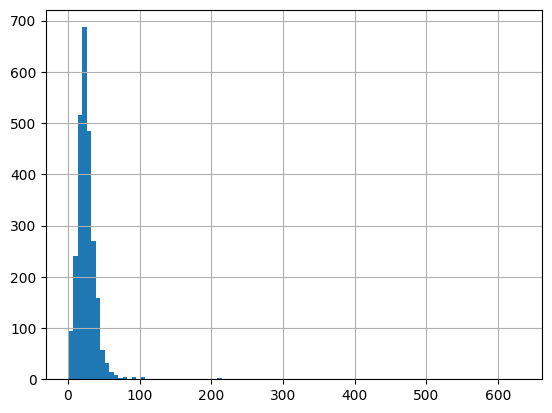

In [129]:
df.exercise_per_week.hist(bins=100)

In [144]:
df2 = df[df.exercise_per_week <= 52]

<Axes: >

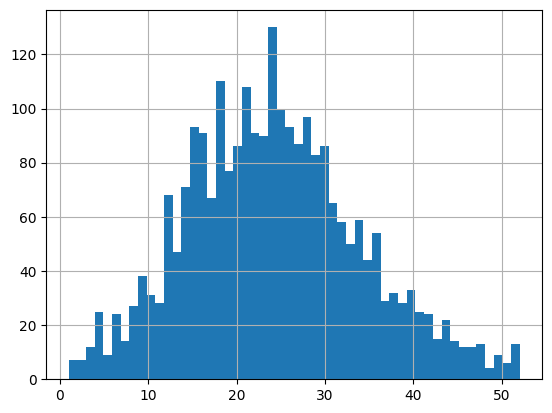

In [146]:
df2.exercise_per_week.hist(bins=52)

<Axes: >

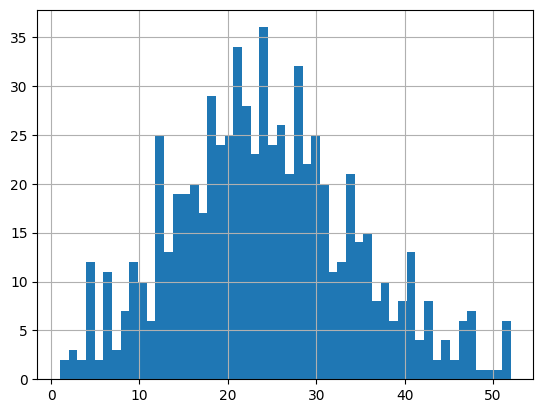

In [157]:
test = df2.level.explode() == 'Beginner'
test[test == 1].index
df2.loc[list(test[test == 1].index),:].exercise_per_week.hist(bins=52)

In [158]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.quantile(0.25)

np.float64(17.0)

In [159]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.median()

np.float64(24.0)

In [160]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.quantile(0.75)

np.float64(31.0)

<Axes: >

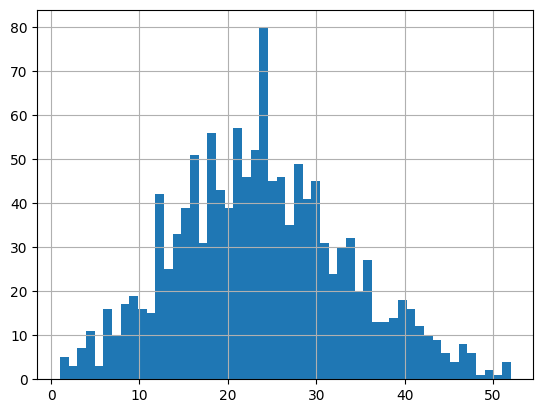

In [161]:
test = df2.level.explode() == 'Novice'
test[test == 1].index
df2.loc[list(test[test == 1].index),:].exercise_per_week.hist(bins=52)

In [162]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.quantile(0.25)

np.float64(17.0)

In [163]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.median()

np.float64(23.791666666666664)

In [164]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.quantile(0.75)

np.float64(30.0)

<Axes: >

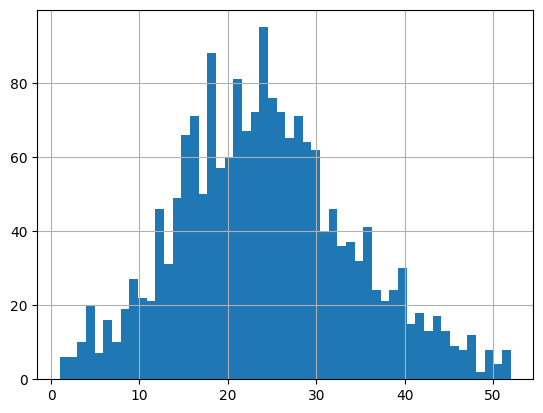

In [165]:
test = df2.level.explode() == 'Intermediate'
test[test == 1].index
df2.loc[list(test[test == 1].index),:].exercise_per_week.hist(bins=52)

In [166]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.quantile(0.25)

np.float64(17.133333333333333)

In [167]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.median()

np.float64(24.0)

In [168]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.quantile(0.75)

np.float64(30.0)

<Axes: >

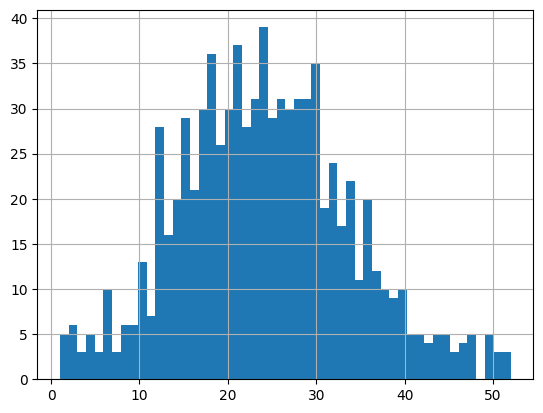

In [169]:
test = df2.level.explode() == 'Advanced'
test[test == 1].index
df2.loc[list(test[test == 1].index),:].exercise_per_week.hist(bins=52)

In [170]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.quantile(0.25)

np.float64(17.270833333333332)

In [171]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.median()

np.float64(24.0)

In [172]:
df2.loc[list(test[test == 1].index),:].exercise_per_week.quantile(0.75)

np.float64(30.0)

# Webslinger exploration

In [13]:
df[df.title == 'Webslinger']

,title,description,level,goal,equipment,program_length,time_per_workout,total_exercises,created,last_edit
2446,Webslinger,READ BEFORE TRAINING \n\n\nThis Program provid...,{Intermediate},[Muscle & Sculpting],At Home,8.0,50.0,5040,2025-05-05 01:38:00,2025-06-18 07:54:00
